https://github.com/karpathy/micrograd/tree/master/micrograd

In [63]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
def f(x):
    return 3*x**2 - 4*x + 5

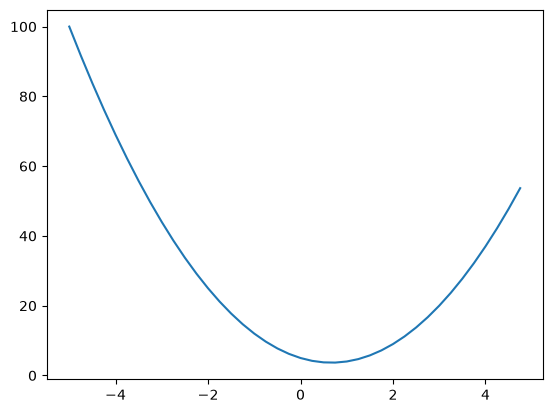

In [65]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [4]:
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

In [5]:
h = 0.0000000001
x = 3.0
(f(x + h) - f(x)) / h

14.000001158365194

In [6]:
h = 0.000000001
x = -3.0
(f(x + h) - f(x)) / h

-22.000001820288162

# Micrograd

In [85]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None #empty function for the backward operation
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad 
        out._backward = _backward

        return out


    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
            
        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self / other
        return self + (-other)

    def __rsub__(self, other):      # other - self
        return other + (-self)

    def __rtruediv__(self, other):  # other / self
        return other * self**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [86]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
        for child in v._prev: 
            edges.add((child, v))
            build(child)
    build(root)
    return nodes, edges

def draw_dot (root):
    dot = Digraph (format='svg', graph_attr={'rankdir': 'LR'}) # LR left to right
    nodes, edges = trace (root)
    for n in nodes:
        uid= str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record') 
        if n._op:
        # if this value is a result of some operation, create an op node for it 
            dot.node (name= uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
    # connect n1 to the op node of n2 
        dot.edge(str(id (n1)), str(id (n2)) + n2._op)
    return dot

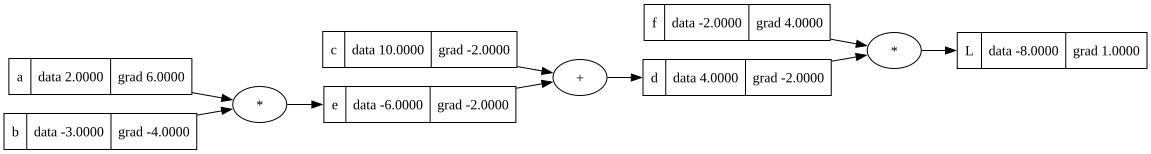

In [46]:
draw_dot(L)

In [ ]:
L = d * f

# dL/dd = f

In [36]:
# L.grad = 1.0
f.grad = 4.0
d.grad = -2.0

dL/dc

dd/dc = 1.0

dd / de = 1.0

d = c + e

(f(x+h) - f(x)) / h

((c+h +e) - (c+e)) / h
(c + h + e - c - e) / h

h / h = 1.0

Chain Rule

WANT:
dL/dc = (dL/dd) * (dd/dc)

KNOW:
DL/dd
dd/dc


WANT:
dL/da = (DL/de) * (de/da)



In [42]:
c.grad = -2.0 
e.grad = -2.0

In [45]:
a.grad = (-2.0 * -3.0)
b.grad = -2.0 * 2.0

In [49]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad


e = a * b
d = e + c
L = d * f

print(L.data)

-5.900192000000001


In [81]:
def lol():

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    c.data += h
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    print((L2 - L1)/h)

lol()
    

-1.9999999999988916


## Neural Backpropagation

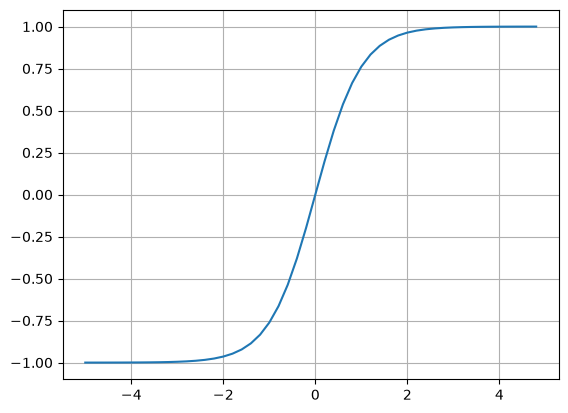

In [68]:
# tanh function
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [69]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

o.backward()

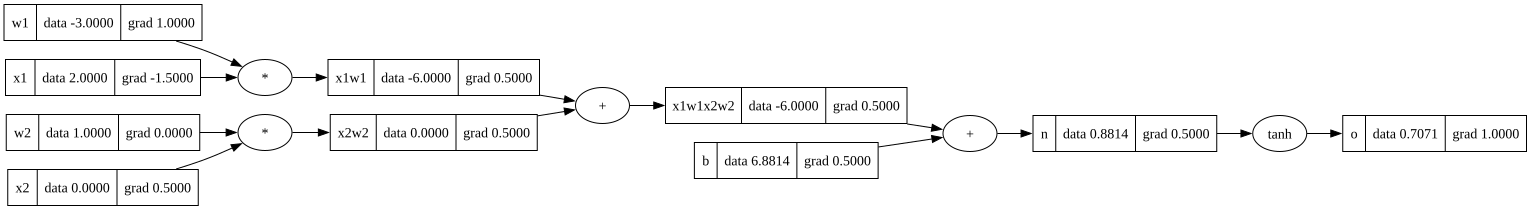

In [106]:
draw_dot(o)

In [100]:
o.backward()

In [84]:
o.grad = 1.0

In [86]:
o._backward()

In [88]:
n._backward()

In [90]:
b._backward()

In [91]:
x1w1x2w2._backward()

In [93]:
x1w1._backward()
x2w2._backward()

In [ ]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [77]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [73]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [63]:
o.grad = 1.0

In [70]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [67]:
n.grad = 0.5

In [66]:
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(h)
# do/dn = 1 - tanh(n)**2  (derivative of tanh function)
# do/dn = 1 - o**2

# Pytorch

In [70]:
import torch

In [71]:
x1 = torch.Tensor([2.0]).double()                   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                   ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()     ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('--------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
--------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [8]:
torch.tensor([[1,2,3], [4,5,6]])

tensor([[1, 2, 3],
        [4, 5, 6]])

In [10]:
x2.grad.item()

0.5000001283844369

In [79]:
import random
import math

In [96]:
# neuron is a functional unit of neural network
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x * b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

# layer is list of neurons
class Layer:

    def __init__(self, nin,  nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

# supporting multi hidden layers (Multi Layer Perceptron)
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [97]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.8314227583902823)

In [74]:
# draw_dot(n(x))

In [98]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.8314227583902823),
 Value(data=0.7952981369231871),
 Value(data=0.7857599070391611),
 Value(data=0.8576205617194926)]

In [99]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.460724036862194)

In [100]:
loss.backward()

In [101]:
n.layers[0].neurons[0].w[0].grad

0.016453626655661083

In [94]:
# draw_dot(loss)

In [103]:
n.parameters()

[Value(data=-0.8436316786146845),
 Value(data=-0.17705574287852688),
 Value(data=-0.9677392926751849),
 Value(data=0.18321600220681833),
 Value(data=0.08654850169326833),
 Value(data=-0.1838436146224034),
 Value(data=-0.5366774566770376),
 Value(data=-0.7734945818163044),
 Value(data=0.5470234634980595),
 Value(data=-0.2733962290363763),
 Value(data=-0.6953963338965634),
 Value(data=0.517678036160381),
 Value(data=-0.03377043757521081),
 Value(data=-0.38564366551596607),
 Value(data=0.6699404013420087),
 Value(data=-0.001038496891777152),
 Value(data=0.20734308605118934),
 Value(data=-0.5743813034331151),
 Value(data=-0.6144844440404147),
 Value(data=-0.4719836694392179),
 Value(data=-0.19268231068115482),
 Value(data=0.880448048466268),
 Value(data=-0.9063078992884288),
 Value(data=-0.009683653448517626),
 Value(data=-0.04413376011111447),
 Value(data=0.8958123382786876),
 Value(data=0.5548142164540968),
 Value(data=0.7667762651537584),
 Value(data=-0.6309744902862335),
 Value(data=0.